<h1> Part 1

The datasets used in this study have been taken from the provided collection of Wikidata talk page data. Using file size as a proxy for network size, the following datasets were chosen:
- BOT_REQUESTS.csv (263 KB) - small network
- ADMINISTRATORS.csv (1.75 MB) - medium network
- USERS.csv (10 MB) - large network

<h2> Task A: Network Construction

In this task, we will construct three networks from the previously chosen datasets.
The networks are named as follows:
- Small-sized network (from BOT_REQUESTS.csv): G_small
- Medium-sized network (from ADMINISTRATORS.csv): G_medium
- Large-sized network (from USERS.csv): G_large

In [2]:
import pandas as pd
import networkx as nx
from itertools import combinations
import random
import matplotlib.pyplot as plt

The build_network() function is used to build the network from a dataset by following this algorithm (later used to answer Question 3):
1. Load the dataset into a Pandas dataframe.
2. Identify all unique users and set them as nodes.
3. Group the data by (page, thread) to identify users participating in the same thread on the same page.
4. For each group, generate all possible pairs of users using pairwise combinations
5. For each pair:
- If an edge doesn’t already exist, add a new edge with weight = 1.
- If an edge already exists, increment the edge weight to match the frequency of interaction.
6. Repeat this process for all groups to construct the complete network.



In [3]:
def build_network(file_path):
    df=pd.read_csv(file_path)
    df.columns=['page', 'thread', 'user'] #renaming for consistency

    G=nx.Graph()
    G.add_nodes_from(df['user'].unique()) #unique users are nodes
    grouped_data=df.groupby(['page', 'thread']) #grouping by page and then thread
    grouped=grouped_data['user'].apply(list)

#edges
    for users in grouped:
        unique_users=list(set(users))
        for user1, user2 in combinations(unique_users,2):
            if G.has_edge(user1,user2):
                G[user1][user2]['weight']+=1
            else:
                G.add_edge(user1,user2,weight=1)

    return G

In [4]:
#building the 3 networks
G_small=build_network("BOT_REQUESTS.csv")
G_medium=build_network("ADMINISTRATORS.csv")
G_large=build_network("USERS.csv")

<h3> Question 1: What elements of the dataset you represented as nodes and edges?

Nodes represent unique Wikidata editors (username).<br>
Edges represent the social connections between users. According to the coursework instructions, two users have a social connection if they both have made a comment in the same thread and on the same page.
The constructed networks are weighted undirected graphs, where the edge weight represents the number of times two users have participated in the same thread on the same page.

Below is a set of sample nodes and edges from the small network (BOT_REQUESTS.csv) to show that nodes are the unique users and edges are the social interactions between users:

In [5]:
print("Sample nodes:",list(G_small.nodes())[:3])
print("Sample edges:",list(G_small.edges(data=True))[:3])

Sample nodes: ['WikidataBotrequestsArchive201302.json', 'WikidataBotrequestsArchive201303.json', 'WikidataBotrequestsArchive201304.json']
Sample edges: [('WikidataBotrequestsArchive201401.json', 'WikidataBotrequestsArchive201406.json', {'weight': 1}), ('WikidataBotrequestsArchive201505.json', 'WikidataBotrequestsArchive201512.json', {'weight': 1}), ('WikidataBotrequestsArchive201509.json', 'WikidataBotrequestsArchive201601.json', {'weight': 2})]


<h3>Question 2: What data structures did you choose to represent this network? How do you keep additional information that cannot be directly encoded as nodes and edges?

The network is implemented using the NetworkX library in Python, which represents graphs using an **adjacency list structure** (which is an efficient representation method even for sparse graphs).

Let's demonstrate this using the medium-sized network G_medium. Shown below is the adjacency list representation for the first 3 nodes:

In [6]:
print(G_medium)

#adjacency list (first 3 nodes)
for i,(node,neighbours) in enumerate(G_medium.adjacency()):
    print("Node:",node)
    print("Adjacency list:",neighbours)
    print()

    if i == 2:
        break

Graph with 110 nodes and 464 edges
Node: WikidataAdministratorsnoticeboardArchive201212.json
Adjacency list: {}

Node: WikidataAdministratorsnoticeboardArchive201301.json
Adjacency list: {}

Node: WikidataAdministratorsnoticeboardArchive201302.json
Adjacency list: {'WikidataAdministratorsnoticeboardArchive201907.json': {'weight': 1}, 'WikidataAdministratorsnoticeboardArchive201311.json': {'weight': 2}}



The adjacency list for each node lists its neighbours along with the edge weights (frequency of interaction with each neighbour).

Additional information like page and thread information are used only during edge construction and not stored later.

<h3>Question 3: What was your algorithmic approach for building the network?

The algorithm (also mentioned at the beginning of the task) for building the network is as follows:
1. Load the dataset into a Pandas dataframe.
2. Identify all unique users and set them as nodes.
3. Group the data by (page, thread) to identify users participating in the same thread on the same page.
4. For each group, generate all possible pairs of users using pairwise combinations
5. For each pair:
- If an edge doesn’t already exist, add a new edge with weight = 1.
- If an edge already exists, increment the edge weight to match the frequency of interaction.
6. Repeat this process for all groups to construct the complete network.


After using this approach to build the networks, here’s the summaries of the three networks using network_summary(), which is used to print network information like number of nodes, number of edges, density and the number of connected components in the network:

In [7]:
def network_summary(G,name):
    print(f'\n{name}')
    print("Nodes:",G.number_of_nodes())
    print("Edges:",G.number_of_edges())
    print("Density:",nx.density(G))
    print("Connected components:",nx.number_connected_components(G))

In [8]:
network_summary(G_small, "Small Network (BOT_REQUESTS.csv): G_small")
network_summary(G_medium, "Medium Network (ADMINISTRATORS.csv): G_medium")
network_summary(G_large, "Large Network (USERS.csv): G_large")


Small Network (BOT_REQUESTS.csv): G_small
Nodes: 108
Edges: 9
Density: 0.001557632398753894
Connected components: 99

Medium Network (ADMINISTRATORS.csv): G_medium
Nodes: 110
Edges: 464
Density: 0.07739783152627189
Connected components: 22

Large Network (USERS.csv): G_large
Nodes: 65076
Edges: 82662160
Density: 0.039039272666254794
Connected components: 4980


<h2>Task B: Network Metrics

After building the networks, we will analyse them with the goal of situating them within the regular network-small world network-random network spectrum, as required by the coursework.

<h3> Question 1. What are the characteristic properties and relevant metrics and distributions of this Wikidata editor network?

For each network, we will analyse:
1. Degree distribution
2. Clustering coefficient
3. Average shortest path length

**Note:** Since USERS.csv is huge, we will not run heavy computations on the full graph G_large. Instead, we will use a randomly sampled subgraph of G_large as sample_G_large. The sample has 5000 nodes, so even that is a large graph compared to the small and medium graphs.<br>
However, this comes with limitations. The original structure and characteristics are often somewhat lost in the sample graph.

In [9]:
sample_nodes=random.sample(list(G_large.nodes()),5000)
sample_G_large=G_large.subgraph(sample_nodes).copy()

**1. Degree Distribution**<br>
The function dd_plot() plots the degree distribution of a network G. The degree of a node in a network is the number of nodes it is connected to.

In [10]:
def dd_plot(G,title):
    degrees=[d for i,d in G.degree()]
    plt.figure()
    plt.hist(degrees,bins=50)
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

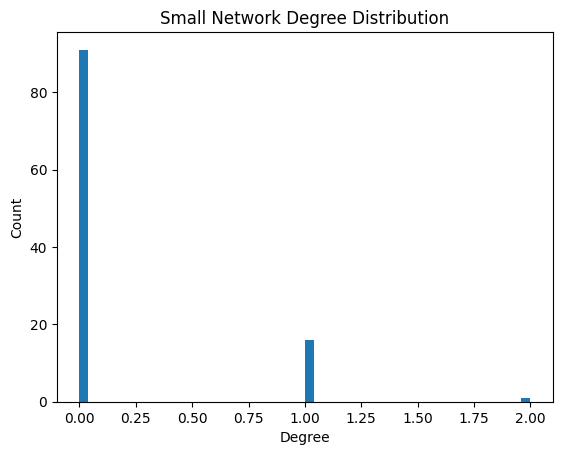

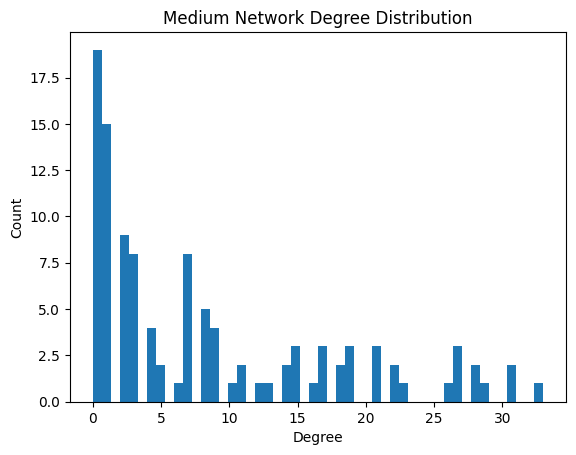

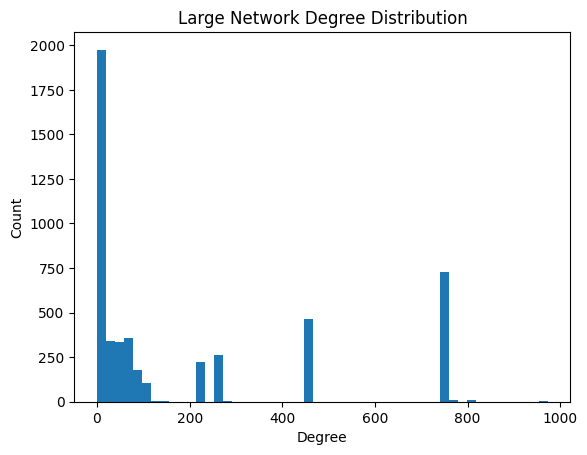

In [11]:
dd_plot(G_small,"Small Network Degree Distribution")
dd_plot(G_medium,"Medium Network Degree Distribution")
dd_plot(sample_G_large,"Large Network Degree Distribution")

We can see that:<br>
- Small network -> Nodes are mostly isolated and the rest are connected to only one or two neighbours. This shows that the degree distribution is relatively uniform, with most nodes having similar degrees. This suggests a lack of complex structure.

- Medium -> The distribution is more skewed, with many nodes having low degree and a few having higher degree. This indicates moving away from a simple structure.

- Large -> Heavy-tailed with a few hubs and many low-degree nodes. The distribution is highly skewed, like real-world social networks.

**2. Clustering Coefficient**<br>
Clustering coefficient measures the degree to which nodes in a network tend to cluster together. For a node, clustering coefficient is calculated as the ratio of existing links between its neighbours to the total possible links between them. The average_clustering() function in NetworkX finds the average of the clustering coefficents of the network's nodes.

In [12]:
print("Small Network Clustering Coefficient: ",nx.average_clustering(G_small))
print("Medium Network Clustering Coefficient: ",nx.average_clustering(G_medium))
print("Large Network Clustering Coefficient: ",nx.average_clustering(sample_G_large))

Small Network Clustering Coefficient:  0.0
Medium Network Clustering Coefficient:  0.366564185121622
Large Network Clustering Coefficient:  0.8175985094590587


High clustering means local, tight-knit communities whereas low clustering means sparse/random distribution of nodes. The results show that clustering increases significantly with network size.

**3. Average Shortest Path Length**<br>
Average Shortest Path Length is calculated as the sum of all shortest path lengths between all distinct pairs of nodes (u,v), divided by the number of pairs n(n-1), where n=total number of nodes.<br>
This metric is only for connected networks. A network is connected only if there is a path between every pair of nodes.<br>
Since the networks we are studying have multiple disconnected components, we cannot compute average shortest path length on the full graph.<br>
We will, therefore, compute it on the Largest Connected Component (LCC).


In [13]:
#largest connected components
def get_lcc(G):
    lcc=max(nx.connected_components(G),key=len)
    return G.subgraph(lcc).copy()

G_s_lcc=get_lcc(G_small)
G_m_lcc=get_lcc(G_medium)
G_l_sample_lcc=get_lcc(sample_G_large)

#average shortest path lengths
print("Small Network Average Shortest Path Length (on LCC): ",nx.average_shortest_path_length(G_s_lcc))
print("Medium Network Average Shortest Path Length (on LCC): ",nx.average_shortest_path_length(G_m_lcc))
print("Large Network Average Shortest Path Length (on LCC): ",nx.average_shortest_path_length(G_l_sample_lcc))

Small Network Average Shortest Path Length (on LCC):  1.3333333333333333
Medium Network Average Shortest Path Length (on LCC):  3.5070836674685912
Large Network Average Shortest Path Length (on LCC):  3.1890939699504797


The average shortest path lengths are relatively small compared to the network sizes.


<h3>Question 2: How different is this network from a random network, according to the various comparison criteria we have seen in class?

**Goals**:
1. Compare real networks to their corresponding random networks
2. Classify each real network into one of the following:
- Random Network
- Regular Network
- Small-World Network

Here, we draw Erdos-Renyi graphs as random networks with the same number of nodes and density to compare to our real networks.

In [14]:
def generate_random_graph(G):
    return nx.erdos_renyi_graph(G.number_of_nodes(),nx.density(G))

#random graphs for the 3 networks
G_small_rd=generate_random_graph(G_small)
G_medium_rd=generate_random_graph(G_medium)
G_large_rd=generate_random_graph(sample_G_large)

Small Random Network:

In [15]:
print("Small Random Network Clustering Coefficient: ",nx.average_clustering(G_small_rd))

G_small_rd_lcc=get_lcc(G_small_rd)
print("Small Random Network Average Shortest Path Length: ",nx.average_shortest_path_length(G_small_rd_lcc))

Small Random Network Clustering Coefficient:  0.0
Small Random Network Average Shortest Path Length:  1.0


Medium Random Network:

In [16]:
print("Medium Random Network Clustering Coefficient: ",nx.average_clustering(G_medium_rd))

G_medium_rd_lcc=get_lcc(G_medium_rd)
print("Medium Random Network Average Shortest Path Length: ",nx.average_shortest_path_length(G_medium_rd_lcc))


Medium Random Network Clustering Coefficient:  0.07049871712551134
Medium Random Network Average Shortest Path Length:  2.4353628023352796


Large Random Network:

In [17]:
print("Large Random Network Clustering Coefficient: ",nx.average_clustering(G_large_rd))

G_large_rd_lcc=get_lcc(G_large_rd)
print("Large Random Network Average Shortest Path Length: ",nx.average_shortest_path_length(G_large_rd_lcc))

Large Random Network Clustering Coefficient:  0.03934374251182659
Large Random Network Average Shortest Path Length:  1.9610393278655731


**Summary:**<br>
Here, <br>
CC = Clustering Coefficient<br>
SPL = Average Shortest Path Length


### Results

| Network Type   | Random CC | Real CC | Random SPL | Real SPL |
|----------------|-----------|---------|------------|----------|
| Small Network  | 0.00      | 0.00    | 1.33       | 1.333    |
| Medium Network | 0.06      | 0.37    | 2.39       | 3.51     |
| Large Network  | 0.04      | 0.82    | 1.97       | 3.19     |

We can classify a network based on the following characteristics:
- Regular → high clustering, long paths
- Random → low clustering, short paths
- Small-world → high clustering short paths

1. **Small Network**
- Same clustering coefficient as random network
- Same average shortest path length as random network
- The small network behaves like a **random network**.

2. **Medium Network**
- Clustering coefficient (Real) >> Clustering coefficient (Random) -> Strong clustering
- Average shortest path length of real network is slightly higher than the random network but still relatively short
- The medium network shows high clustering compared to the random network while maintaining a relatively short average shortest path length -> **Small-world behaviour**

3. **Large Network**
- Clustering coefficient (Real) >> Clustering coefficient (Random) -> Extremely strong clustering
- Average shortest path length of real network is moderately higher than the random network but still relatively short relative to size
- The large network shows substantially higher clustering and a low average shortest path length compared to size -> **Strong small-world behaviour**

Overall, the results show a clear transition from a random-like structure in the small network to increasingly pronounced small-world characteristics in the medium and large networks. As network size increases, clustering becomes significantly stronger while path lengths remain relatively short.

<h3>Question 3: If you take this network as a complete and representative description of editor networks in collaborative knowledge projects like Wikipedia and Wikidata, what does it tell you about the way editors talk among themselves and their social activity and connections?

The small network behaves similarly to a random network, with no clustering and no clear structure. This suggests that interactions are limited and do not form meaningful social groups. The medium network, on the other hand, shows higher clustering, indicating that editors begin to form local discussion groups around certain topics. Although interactions are more structured, connectivity across the network is still relatively limited. The large network exhibits strong small-world characteristics, with very high clustering and relatively short path lengths. This suggests that editors form tightly connected communities, while still remaining part of a larger, well-connected network. The presence of highly connected users (hubs) also indicates that some editors play a more central role in discussions. Overall, as the network size increases, editor interactions become more structured, moving from random behaviour to organised communities with efficient communication.

<h2>Task C: Epidemic Models

To analyse how controversial behaviour like trolling may spread among editors, the network is treated as a social interaction graph, where nodes represent editors and edges represent repeated co-participation in discussions.

<h3>Question 1: If both editors have been commenting more than usual on the same day (i.e. might be controversial, trolling, etc.), how can they use the network data to judge how plausible it is that this behaviour has not propagated yet to neighbouring similar editors?

To assess whether controversial behaviour has already propagated between two editors, the network is analysed using both structural properties and an epidemic model.<br>
We assume that once an editor becomes infected (i.e. starts showing unusual behaviour), they stay infected without recovery. Therefore, we do not use a SIR (Susceptible-Infected-Recovered) or SIS (Susceptible-Infected-Susceptible) epidemic model here. Instead, we take inspiration from the simple Susceptible-Infected (SI) model to simulate how trolling behaviour spreads through the network. Here:<br>
- Susceptible (S): Normal editors
- Infected (I): editors showing unusual/controversial behaviour
- Infected editors can spread the behaviour to their neighbours with a given probability (beta)<br>

Since interactions are two-way, connected users are more likely to influence each other.<br>
In addition to simulation, structural properties such as shortest path distance and shared neighbours are used to evaluate how easily behaviour can propagate between editors.

First, we will randomly select two editors as asked.<br>

Then we move on to structurally analysing the spread of trolling behaviour:<br>
A small distance between editors suggests that they are closely connected, increasing the likelihood that behaviour has already propagated. Additionally, shared neighbours indicate local clustering, which further increases the probability of spread. Thus, large distances and lack of shared neighbours suggest that the behaviour may not yet have propagated.<br>

This is why we will calculate the shortest path distance between editors and their shared neighbours for each network.

In [29]:
def structural_analysis(G):
    node1,node2=random.sample(list(G.nodes()), 2) #2 editors showing unusual behaviour
    print("Selected Editors:")
    print("Editor 1:",node1)
    print("Editor 2:",node2)

    #shortest path distance
    try:
        sp_distance=nx.shortest_path_length(G,node1,node2)
    except nx.NetworkXNoPath:
        sp_distance=float('inf')
    print("\nShortest Path Distance between them:",sp_distance)


    #shared neighbours of editors
    neighbours1=set(G.neighbors(node1))
    neighbours2=set(G.neighbors(node2))
    print("\nNumber of neighbours:")
    print("Editor 1:",len(neighbours1))
    print("Editor 2:",len(neighbours2))
    shared_n=neighbours1.intersection(neighbours2)
    print("\nNo. of shared neighbours:",len(shared_n))
    print("Sample shared neighbours:",list(shared_n)[:10])


    print("\nInterpretation in terms of trolling behaviour propagation:")
    if sp_distance==float('inf'):
        print("Editors are not connected → propagation unlikely.")
    elif sp_distance<=2:
        print("Editors are very close → high chance of propagation")
    elif sp_distance<=4:
        print("Editors moderately close → possible propagation.")
    else:
        print("Editors far apart → propagation less likely.")

    if len(shared_n)>0:
        print("Shared neighbours exist → local spread likely.")
    else:
        print("No shared neighbours → local spread less likely.")

    return node1, node2, sp_distance, shared_n

Using shortest path distance between the editors and the number of shared neighbours between them, we are categorising as follows:<br>

Distance between editors:
- If no path exists (distance=infinity): editors are not connected and therefore propagation of trolling behaviour is unlikely.
- If distance<=2: editors are really close and therefore high chance of propagation.
- If distance<=4: editors are moderately close and therefore propagation is likely.
- For greater distances, propagation is less likely.

Shared neighbours:<br>
- If shared neighbours exist: Local spread is likely.
- No shared neighbours: Local spread less likely.

Now we will do the behaviour (epidemic) spread analysis inspired by the SI (Susceptible–Infected) model.
We start from one infected editor from whom the behaviour spreads to neighbouring editors with a fixed probability beta (We choose beta value as 0.2 or 20% throughout, indicating a balanced probability of spread). At each step, newly infected nodes can further spread the behaviour to their neighbours. Repeating this process for a small number of steps shows how trolling behaviour can cascade through the network. The final set of infected nodes represents the potential spread from the initial editor.

In [30]:
def epidemic_analysis(G,start,beta=0.2,steps=2):
    infected={start} #set of infected nodes

    for i in range(steps):
        new_inf=set()
        for n in infected:
            for neighbour in G.neighbors(n):
                if neighbour not in infected:
                    if random.random()<beta: #randomly infect neighbour
                        new_inf.add(neighbour)
        infected.update(new_inf)
    return infected

Combine both analyses:

In [25]:
def combined_analysis(G):
    node1,node2,distance,shared=structural_analysis(G)

    inf1=epidemic_analysis(G,node1) #infected nodes starting from node 1
    inf2=epidemic_analysis(G,node2) #infected nodes starting from node 2
    overlap=inf1.intersection(inf2) #nodes infected by both
    print("\nEpidemic Spread Overlap:",len(overlap))


We find the users who have been influenced by both editors. Starting from each editor, the SI model simulates the spread to neighbouring nodes. If the simulated infected sets overlap significantly, this suggests that the behaviour has likely propagated to many users by the two editors or through common neighbours. If there is little to no overlap, it is more likely that the behaviour has not yet spread.

Now we will apply this combined analysis to our networks.<br>
Note: We will be using the sample of G_large instead of the full network.

In [26]:
print("Small Network:")
combined_analysis(G_small)

Small Network:
Selected Editors:
Editor 1: WikidataBotrequestsArchive201510.json
Editor 2: WikidataBotrequestsArchive201912.json

Shortest Path Distance between them: inf

Number of neighbours:
Editor 1: 1
Editor 2: 0

No. of shared neighbours: 0
Sample shared neighbours: []

Interpretation in terms of trolling behaviour propagation:
Editors are not connected → propagation unlikely.
No shared neighbours → local spread less likely.

Epidemic Spread Overlap: 0


Since the editors are not connected, have no shared neighbours and no spread overlap, behaviour propagation is unlikely.

In [33]:
print("\nMedium Network:")
combined_analysis(G_medium)


Medium Network:
Selected Editors:
Editor 1: WikidataAdministratorsnoticeboardArchive201808.json
Editor 2: WikidataAdministratorsnoticeboardArchive202002.json

Shortest Path Distance between them: 2

Number of neighbours:
Editor 1: 9
Editor 2: 19

No. of shared neighbours: 5
Sample shared neighbours: ['WikidataAdministratorsnoticeboardArchive201903.json', 'WikidataAdministratorsnoticeboardArchive202004.json', 'WikidataAdministratorsnoticeboardArchive201807.json', 'WikidataAdministratorsnoticeboardArchive201902.json', 'WikidataAdministratorsnoticeboardArchive201904.json']

Interpretation in terms of trolling behaviour propagation:
Editors are very close → high chance of propagation
Shared neighbours exist → local spread likely.

Epidemic Spread Overlap: 8


Since the editors are really close to each other, have shared neighbours and moderate spread overlap, behaviour propagation is quite likely.

In [46]:
print("\nLarge Network (sample):")
combined_analysis(sample_G_large)


Large Network (sample):
Selected Editors:
Editor 1: UsertalkLimonaiawikidatawiki.json
Editor 2: UsertalkBombo.json

Shortest Path Distance between them: 2

Number of neighbours:
Editor 1: 286
Editor 2: 748

No. of shared neighbours: 5
Sample shared neighbours: ['UsertalkTSUBAME98wikidatawiki.json', 'UsertalkThomas74.json', 'UsertalkVsuarezp.json', 'UsertalkWikid77.json', 'UsertalkIreumeopseumwikidatawiki1.json']

Interpretation in terms of trolling behaviour propagation:
Editors are very close → high chance of propagation
Shared neighbours exist → local spread likely.

Epidemic Spread Overlap: 153


Here too, the editors are really close to each other and have shared neighbours but the spread overlap is extremely high, suggesting that the chance of behaviour propagation is extremely high.

We run the analysis a couple of times to see the general behaviour of each network.

<h3>Question 2: If one or both of the tested editors have indeed been “possibly trolling”, then the Foundation will start checking other editors as well, prioritising those with a higher chance of having been trolling. How should they use the data to come up with a priority list on what editors to check first?

Once one or both editors are identified as possibly trolling, the goal is to prioritise which other editors should be checked next. This can be approached using an epidemic model. In the SI model, nodes that are directly connected to infected nodes have the highest probability of becoming infected. Also, nodes connected to multiple infected editors have an even higher probability due to repeated exposure.

Therefore, priority is determined based on proximity to infected editors (neighbours), number of infected neighbours (repeated exposure), interaction strength (edge weights) and node connectivity (degree).

**Case 1. Priority ranking if one editor is trolling:**<br>
To prioritise which editors to check next, a score is assigned to each neighbour of the infected editor where score=(beta*edge weight)+degree.
<br>Here,
- beta=probability of spreading the infection to a neighbour
- edge weight=frequency of interaction between the two users
- degree=how many other users the neighbour is connected to

Higher score values indicate a greater likelihood of being influenced or spreading the behaviour further. The neighbours are then ranked based on this score, and the top candidates are selected as the highest priority for checking.

In [47]:
def one_troll_priority_10(G,infected,beta=0.2):
    scores={} #priority list of users with score based on how likely they are to be trolling too

    for n in G.neighbors(infected):
        deg=G.degree(n) #degree of neighbours
        weight=G[infected][n].get('weight',1) #edge weights with neighbours

        score=beta*weight+deg
        scores[n]=score #give a score to each neighbour
    ranked_users=sorted(scores.items(),key=lambda x:x[1],reverse=True)
    return ranked_users[:10]

**Case 2. Priority ranking if two editors are trolling:**<br>
For each node, a score is calculated as: score=(beta x weight1)+(beta x weight2)+repeated exposure+degree, where:<br>
- beta=probability of infection spread
- weight1=interaction strength (edge weight) with editor 1
- weight2=interaction strength (edge weight) with editor 2
- repeated exposure=1 if the node is connected to both users, 0 otherwise
- degree=total no. of connections of the node
So more interaction with an editor, having connections to both editors and having more connections all lead to a higher score for a node. The nodes are then ranked on the basis of score, and the ones with the highest scores are checked first.

In [48]:
def two_troll_priority_10(G,troll1,troll2,beta=0.2):
    scores={}
    neighbours1=set(G.neighbors(troll1)) #neighbours of trolls
    neighbours2=set(G.neighbors(troll2))

    for n in neighbours1.union(neighbours2):
        score=0

        #add degree
        score+=G.degree(n)

        #exposure from troll1
        if n in neighbours1:
            weight1=G[troll1][n].get('weight',1)
            score+=beta*weight1

        #exposure from troll2
        if n in neighbours2:
            weight2=G[troll2][n].get('weight',1)
            score+=beta*weight2

        #repeated exposure
        if n in neighbours1 and node in neighbours2:
            score+=1

        scores[n]=score

    ranked_list=sorted(scores.items(),key=lambda x:x[1],reverse=True)

    return ranked_list[:10]

Running both functions on the networks:<br>
We choose two random editors for every network as potential trolls.

In [50]:
node1,node2=random.sample(list(G_small.nodes()), 2) #trolls
print("Small Network:")
print("Editor 1:",node1)
print("Editor 2:",node2)

print("\nTop priority nodes to check (one editor trolling):")
print(one_troll_priority_10(G_small,node1))

print("\nTop priority nodes to check (two editors trolling):")
print(two_troll_priority_10(G_small,node1,node2))

Small Network:
Editor 1: WikidataBotrequestsArchive201912.json
Editor 2: WikidataBotrequestsArchive201303.json

Top priority nodes to check (one editor trolling):
[]

Top priority nodes to check (two editors trolling):
[]


In [51]:
node1,node2=random.sample(list(G_medium.nodes()), 2) #trolls
print("Medium Network:")
print("Editor 1:",node1)
print("Editor 2:",node2)

print("\nTop priority nodes to check (one editor trolling):")
print(one_troll_priority_10(G_medium,node1))

print("\nTop priority nodes to check (two editors trolling):")
print(two_troll_priority_10(G_medium,node1,node2))

Medium Network:
Editor 1: WikidataAdministratorsnoticeboardArchive202012.json
Editor 2: WikidataAdministratorsnoticeboardArchive201507.json

Top priority nodes to check (one editor trolling):
[('WikidataAdministratorsnoticeboardArchive201907.json', 31.2), ('WikidataAdministratorsnoticeboardArchive202004.json', 28.2), ('WikidataAdministratorsnoticeboardArchive202001.json', 22.2), ('WikidataAdministratorsnoticeboardArchive202006.json', 19.2), ('WikidataAdministratorsnoticeboardArchive201611.json', 10.2), ('WikidataAdministratorsnoticeboardArchive202109.json', 9.2), ('WikidataAdministratorsnoticeboardArchive202106.json', 7.2), ('WikidataAdministratorsnoticeboardArchive202101.json', 7.2)]

Top priority nodes to check (two editors trolling):
[('WikidataAdministratorsnoticeboardArchive201907.json', 31.2), ('WikidataAdministratorsnoticeboardArchive202004.json', 28.2), ('WikidataAdministratorsnoticeboardArchive202001.json', 22.2), ('WikidataAdministratorsnoticeboardArchive202006.json', 19.2), 

In [52]:
node1,node2=random.sample(list(sample_G_large.nodes()), 2) #trolls
print("Sample Large Network:")
print("Editor 1:",node1)
print("Editor 2:",node2)

print("\nTop priority nodes to check (one editor trolling):")
print(one_troll_priority_10(sample_G_large,node1))

print("\nTop priority nodes to check (two editors trolling):")
print(two_troll_priority_10(sample_G_large,node1,node2))

Sample Large Network:
Editor 1: UsertalkArosioStefano.json
Editor 2: UsertalkBjschoenmakers.json

Top priority nodes to check (one editor trolling):
[('UsertalkWla.json', 127.2), ('UsertalkFabC.json', 89.2), ('UsertalkSakretsu.json', 84.2), ('UsertalkFra00.json', 76.2), ('UsertalkManuelarosi.json', 74.2), ('UsertalkLongo73.json', 70.2), ('UsertalkEnryonthecloud.json', 70.2), ('UsertalkMattia94raggio.json', 70.2), ('UsertalkNazasca.json', 70.2), ('UsertalkMoroder.json', 70.2)]

Top priority nodes to check (two editors trolling):
[('UsertalkWla.json', 127.2), ('UsertalkFabC.json', 89.2), ('UsertalkSakretsu.json', 84.2), ('UsertalkFra00.json', 76.2), ('UsertalkManuelarosi.json', 74.2), ('UsertalkEnryonthecloud.json', 70.2), ('UsertalkAle300885.json', 70.2), ('UsertalkJaps88.json', 70.2), ('UsertalkMattia94raggio.json', 70.2), ('UsertalkLongo73.json', 70.2)]


We run the analysis a couple of times to see the general behaviour of each network.

To summarise, we create the priority list by estimating which editors have the highest probability of being “infected” under an epidemic model. If only one editor is trolling, the direct neighbours are the likeliest to get influenced as they are directly exposed to the behaviour. Among these, editors with stronger interaction weights and higher connectivity (degree) are prioritised, as they are more likely to both receive and further propagate the behaviour. On the other hand, if both editors are trolling, priority is given to editors who are connected to both individuals as they get repeated exposure and have the highest likelihood of being influenced. Additionally, nodes with high degree are prioritised, as they can further propagate the behaviour.

This method thus helps identify editors who are most likely to be influenced or influence others. Focusing on these highly exposed and highly connected editors can help detect trolling behaviour early on and thus prevent it before it spreads too much.

The three networks show clear differences in structure and behaviour. Since the small network behaves like a random network with no meaningful connections between nodes, the priority lists are empty which shows that there is practically no propagation of trolling behaviour, as editors are not strongly connected. On the other hand, the medium network is more structured with certain nodes consistently appearing in the priority lists with moderate scores. This indicates that we have local clusters within which the behaviour can spread but not necessarily across the entire network. This aligns with the medium network's weak small-world behaviour where clustering exists but global connectivity is still limited.<br>
The large network shows strong small-world behaviour, with very high priority scores and the same key nodes appearing repeatedly. This suggests that some editors are highly connected and act as hubs, making it easier for trolling behaviour to spread across the network. Compared to random or regular networks, it has high clustering and relatively short paths, which makes propagation easier. However, these results might not be completely reliable as they are affected by how the network is constructed. Firstly, the subgraph created through random sampling does not always retain important global network structure and characteristics. Secondly, edges combine interactions across different threads which can result in increased clustering and connectivity, possibly making the behaviour spread seem easier than it actually is.